## Imports

In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import scipy.ndimage.filters as filters

## Load in images

In [ ]:
folder_path = Path("./materialy_feature_points")
extensions = ["*.png", "*.jpg"]

image_paths = []
for ext in extensions:
    image_paths.extend(folder_path.glob(ext))

images = []
for path in image_paths:
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    
    images.append(img)

## Harris Method

In [21]:
fountain_1 = images[4]
fountain_2 = images[5]

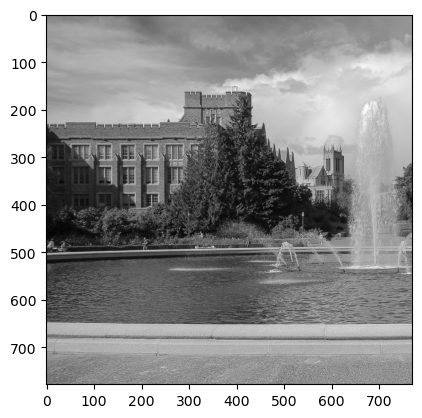

In [43]:
plt.gray()
plt.imshow(fountain_1)

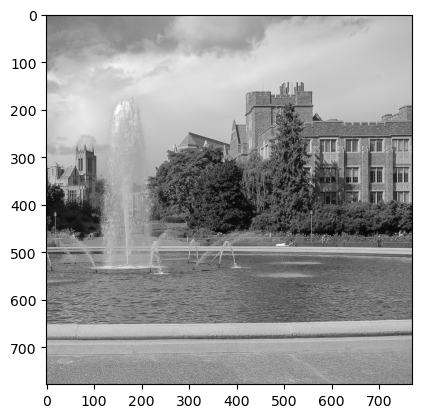

In [41]:
plt.imshow(fountain_2)

In [22]:
def find_max(image, size, threshold) : # size - maximum filter mask size
    data_max = filters.maximum_filter(image, size)
    maxima = (image == data_max)
    diff = image > threshold
    maxima[diff == 0] = 0
    return np.nonzero(maxima)

In [35]:
def get_h_from_auto_corelation_matrix(image, sobel_size, gauss_size, K=0.05):
    # Gradient with Sobel
    Ix = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=sobel_size)
    Iy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=sobel_size)

    I2x = Ix**2
    I2y = Iy**2
    Ixy = Ix * Iy

    # Applying Gaussian blur
    gauss_tuple = (gauss_size, gauss_size)
    blurred_I2x = cv2.GaussianBlur(I2x, ksize=gauss_tuple, sigmaX=1)
    blurred_I2y = cv2.GaussianBlur(I2y, ksize=gauss_tuple, sigmaX=1)
    blurred_Ixy = cv2.GaussianBlur(Ixy, ksize=gauss_tuple, sigmaX=1)

    det = blurred_I2x * blurred_I2y - (blurred_Ixy) ** 2
    trace = blurred_I2x + blurred_I2y

    return det - K * trace ** 2

In [42]:
fountaint_1_H = get_h_from_auto_corelation_matrix(fountain_1, 7, 7)
fountaint_2_H = get_h_from_auto_corelation_matrix(fountain_2, 7, 7)

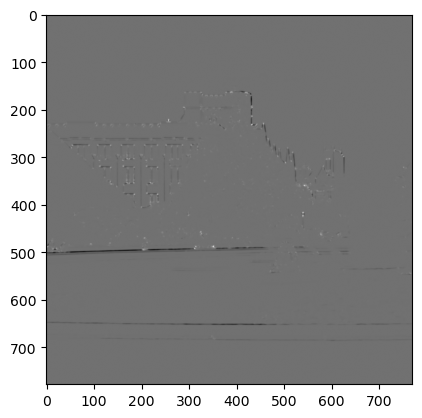

In [45]:
plt.imshow(fountaint_1_H)

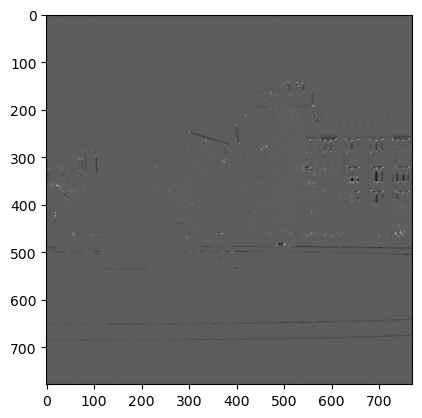

In [46]:
plt.imshow(fountaint_2_H)

In [37]:
find_max(H, 7, 127)

C:\Users\Dell\AppData\Local\Temp\ipykernel_80140\1870468016.py:2: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  data_max = filters.maximum_filter(image, size)


(array([  0,   0,   0, ..., 777, 777, 777], shape=(6317,)),
 array([  3,  28,  72, ..., 642, 742, 765], shape=(6317,)))